In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
 

In [3]:
import pandas as pd

df = pd.read_csv(path + "/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
data =df.drop(['Time'], axis=1)
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
from matplotlib import rcParams

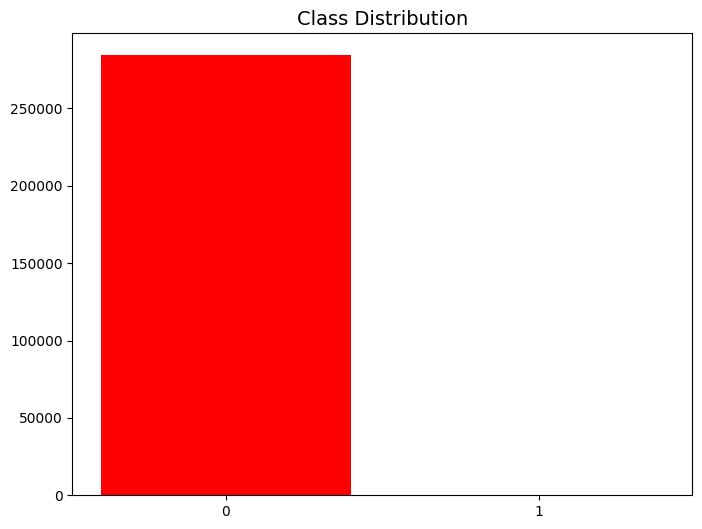

In [6]:
rcParams['figure.figsize'] = 8, 6
plt.bar(data['Class'].unique(), data['Class'].value_counts(), color=['red', 'green'])
plt.xticks([0, 1])
plt.title("Class Distribution", fontsize=14)
plt.show()

In [7]:
x= df.drop('Class',axis=1)
y=df['Class']

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
Hp_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1,2,3,4,5,10,15,20]
}

tree_GS_param = GridSearchCV(
    DecisionTreeClassifier(),   
    Hp_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

tree_GS_param.fit(x_train, y_train)

print("The best parameters combined is ------ ")
print(tree_GS_param.best_params_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
The best parameters combined is ------ 
{'criterion': 'entropy', 'max_depth': 3}


In [11]:
y_pred = tree_GS_param.predict(x_test)

In [12]:
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))
 
#Calculate sensitivity and specificity
 
total1=sum(sum(cm1))
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)
 
sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )
 
specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

[[56852    12]
 [   21    77]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56864
       Fraud       0.87      0.79      0.82        98

    accuracy                           1.00     56962
   macro avg       0.93      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.999420666409185
Sensitivity :  0.9997889701744513
Specificity :  0.7857142857142857


In [13]:
pip install graphviz

In [15]:
from sklearn.tree import export_graphviz
from sklearn import tree
import graphviz
import pydotplus
from IPython.display import Image



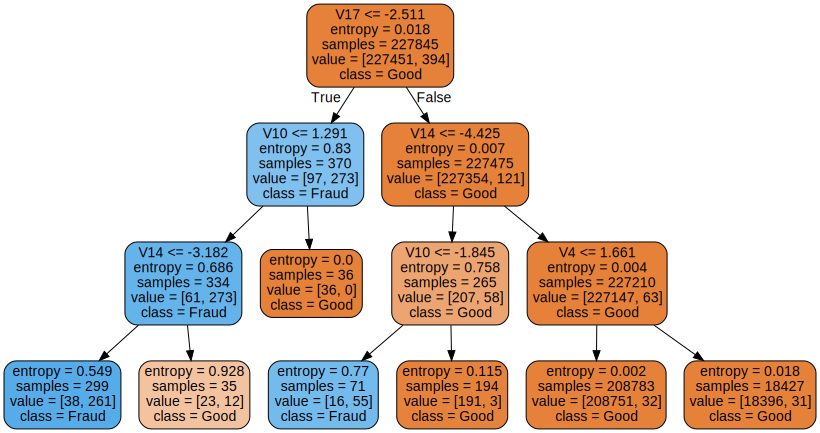

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

best_model = tree_GS_param.best_estimator_

dot_data = export_graphviz(
    best_model,
    out_file=None,
    feature_names=x_train.columns,
    class_names=["Good", "Fraud"],
    filled=True,
    rounded=True
)

graph = graphviz.Source(dot_data)
graph

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

Hyper_paramters = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0]
}

Tree_Gridsearch_parameters = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier()), 
    Hyper_paramters,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=2
)

Tree_Gridsearch_parameters.fit(x_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [ ]:
# طباعة أفضل combination للـ hyperparameters
print("The best parameter combination is:")
print(Tree_Gridsearch_parameters.best_params_)  # gets best estimator

# الحصول على أفضل موديل
Final_Model = Tree_Gridsearch_parameters.best_estimator_  # gets best estimator

# طباعة أفضل AUC score
print("The best AUC score was:")
print(Tree_Gridsearch_parameters.best_score_)

The best parameter combination is:


AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameters
Hyper_paramters_RF = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 10],
    'n_estimators': [50, 100],
    'max_features': ['sqrt']
}

# GridSearch
Tree_Gridsearch_parameters = GridSearchCV(
    RandomForestClassifier(),
    Hyper_paramters_RF,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=2
)

# Fit
Tree_Gridsearch_parameters.fit(x_train, y_train)

# Best parameters
print("The best parameter combination is:")
print(Tree_Gridsearch_parameters.best_params_)

# Best model
Final_Model = Tree_Gridsearch_parameters.best_estimator_

# Best AUC
print("The best AUC score was:")
print(Tree_Gridsearch_parameters.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


KeyboardInterrupt: 